# 🪐 Notebook #54 — Exoplanet Detection Analytics
## Production ML Portfolio | Australian Government Policy Framing

**Policy Context:**  
The **Australian Space Agency**, **CSIRO Space & Astronomy**, and the **Square Kilometre Array (SKA) Observatory** in Western Australia represent Australia's growing investment in space science and deep-sky research. Classifying exoplanet discovery methods and predicting orbital characteristics (period, distance) directly supports the **Australian Civil Space Strategy 2019–2028** and positions Australian research institutions in global space data pipelines. Machine learning applied to astronomical survey data accelerates discovery workflows and reduces manual curation overhead.

**Relevant Agencies:** Australian Space Agency · CSIRO Space & Astronomy · SKA Observatory · ARC (Australian Research Council) · Dept of Industry, Science and Resources

---
**Dataset:** Seaborn built-in `planets` — Exoplanet discoveries (1,035 rows, 6 features, 2006–2014)  
**Task:** Multiclass Classification (detection method) + Regression (orbital period)  
**Models:** LogReg · Random Forest · XGBoost · LightGBM  
**Author:** Dean (Kaggle: deanbatur | GitHub: Deanmeisong)

## 1. 📦 Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings, os, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
print('✅ Libraries loaded')

✅ Libraries loaded


## 2. 📂 Data Loading — Seaborn `planets` (Auto-detect CSV fallback)

In [2]:
# ── Primary: seaborn built-in ──────────────────────────────────────────────
df = sns.load_dataset('planets')
print(f'Seaborn planets loaded: {df.shape}')
print(df.head(8))

# ── Fallback: auto-detect CSV from /kaggle/input/ ─────────────────────────
if df is None or df.empty:
    base = '/kaggle/input'
    csvs = [os.path.join(r, f)
            for r, _, files in os.walk(base)
            for f in files if f.endswith('.csv')]
    if csvs:
        df = pd.read_csv(csvs[0], encoding='latin-1')
        print(f'CSV fallback: {csvs[0]} → {df.shape}')

# ── Sample large datasets to 30K ──────────────────────────────────────────
if len(df) > 30000:
    df = df.sample(30000, random_state=SEED).reset_index(drop=True)

print(f'\nShape: {df.shape}')
print(df.dtypes)
print(f'\nDetection methods: {df["method"].value_counts().to_dict() if "method" in df.columns else "N/A"}')

Seaborn planets loaded: (1035, 6)
            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009
5  Radial Velocity       1         185.840   4.80     76.39  2008
6  Radial Velocity       1        1773.400   4.64     18.15  2002
7  Radial Velocity       1         798.500    NaN     21.41  1996

Shape: (1035, 6)
method             object
number              int64
orbital_period    float64
mass              float64
distance          float64
year                int64
dtype: object

Detection methods: {'Radial Velocity': 553, 'Transit': 397, 'Imaging': 38, 'Microlensing': 23, 'Eclipse Timing Variations': 9, 'Pulsar Timing': 5, 'Transit Timing Variations': 4, 'Orb

## 3. 🎯 Target Detection & Task Setup

In [3]:
# ── Classification target: detection method ────────────────────────────────
target_clf = 'method'
print(f'Classification target: {target_clf}')
print(df[target_clf].value_counts())

# Consolidate rare methods into 'Other' (keep top 4)
top_methods = df[target_clf].value_counts().nlargest(4).index.tolist()
df[target_clf] = df[target_clf].apply(lambda x: x if x in top_methods else 'Other')
print(f'\nAfter consolidation:')
print(df[target_clf].value_counts())

# ── Regression target: orbital period ─────────────────────────────────────
target_reg = 'orbital_period'
print(f'\nRegression target: {target_reg}')
print(df[target_reg].describe().round(2))
print(f'Missing in orbital_period: {df[target_reg].isna().sum()}')

Classification target: method
method
Radial Velocity                  553
Transit                          397
Imaging                           38
Microlensing                      23
Eclipse Timing Variations          9
Pulsar Timing                      5
Transit Timing Variations          4
Orbital Brightness Modulation      3
Astrometry                         2
Pulsation Timing Variations        1
Name: count, dtype: int64

After consolidation:
method
Radial Velocity    553
Transit            397
Imaging             38
Other               24
Microlensing        23
Name: count, dtype: int64

Regression target: orbital_period
count       992.00
mean       2002.92
std       26014.73
min           0.09
25%           5.44
50%          39.98
75%         526.00
max      730000.00
Name: orbital_period, dtype: float64
Missing in orbital_period: 43


## 4. 🔍 Exploratory Data Analysis

In [4]:
print('=== Missing values ===')
print(df.isnull().sum())
print(f'\nYear range: {df["year"].min()} – {df["year"].max()}' if 'year' in df.columns else '')

=== Missing values ===
method              0
number              0
orbital_period     43
mass              522
distance          227
year                0
dtype: int64

Year range: 1989 – 2014


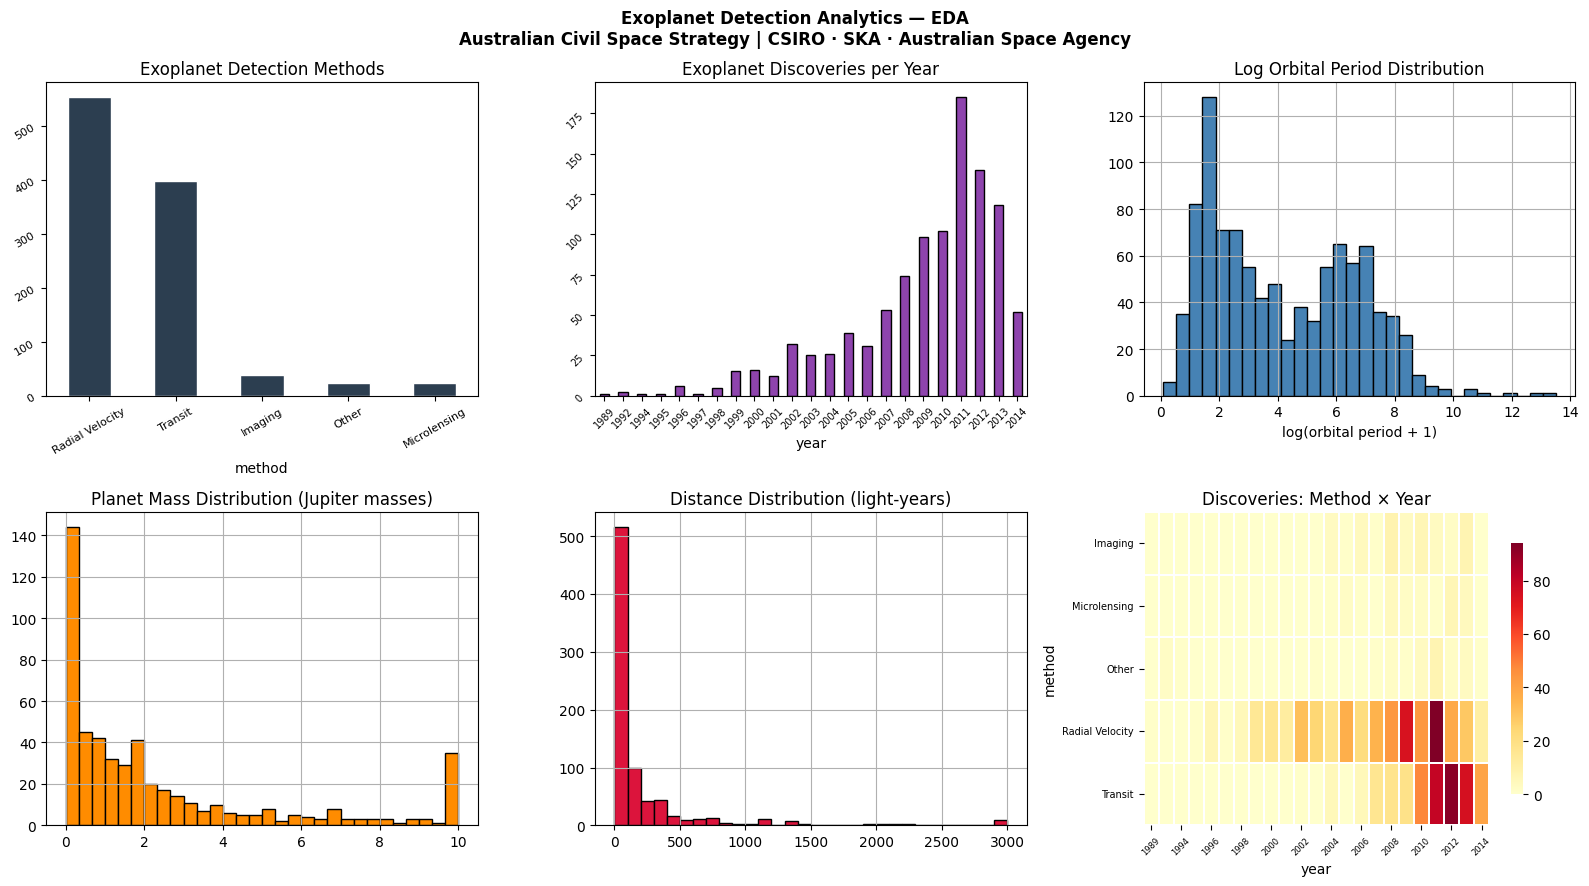

✅ EDA complete


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exoplanet Detection Analytics — EDA\nAustralian Civil Space Strategy | CSIRO · SKA · Australian Space Agency',
             fontsize=12, fontweight='bold')

# 1. Detection method distribution
df[target_clf].value_counts().plot(kind='bar', ax=axes[0,0], color='#2c3e50', edgecolor='white')
axes[0,0].set_title('Exoplanet Detection Methods')
axes[0,0].tick_params(rotation=30, labelsize=8)

# 2. Discoveries per year
if 'year' in df.columns:
    df.groupby('year').size().plot(kind='bar', ax=axes[0,1], color='#8e44ad', edgecolor='black')
    axes[0,1].set_title('Exoplanet Discoveries per Year')
    axes[0,1].tick_params(rotation=45, labelsize=7)

# 3. Orbital period distribution (log scale)
if target_reg in df.columns:
    df[target_reg].dropna().apply(np.log1p).hist(ax=axes[0,2], bins=30, color='steelblue', edgecolor='black')
    axes[0,2].set_title('Log Orbital Period Distribution')
    axes[0,2].set_xlabel('log(orbital period + 1)')

# 4. Mass distribution
if 'mass' in df.columns:
    df['mass'].dropna().clip(0, 10).hist(ax=axes[1,0], bins=30, color='darkorange', edgecolor='black')
    axes[1,0].set_title('Planet Mass Distribution (Jupiter masses)')

# 5. Distance distribution
if 'distance' in df.columns:
    df['distance'].dropna().clip(0, 3000).hist(ax=axes[1,1], bins=30, color='crimson', edgecolor='black')
    axes[1,1].set_title('Distance Distribution (light-years)')

# 6. Method by year heatmap
if 'year' in df.columns:
    method_year = df.groupby(['year', target_clf]).size().unstack(fill_value=0)
    sns.heatmap(method_year.T, ax=axes[1,2], cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    axes[1,2].set_title('Discoveries: Method × Year')
    axes[1,2].tick_params(axis='x', rotation=45, labelsize=6)
    axes[1,2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('eda_planets.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ EDA complete')

## 5. 🔧 Feature Engineering

In [6]:
df_fe = df.copy()

# ── Log-transform skewed numeric features ────────────────────────────────
for col in ['orbital_period', 'mass', 'distance', 'semi_major_axis']:
    if col in df_fe.columns:
        df_fe[f'log_{col}'] = np.log1p(df_fe[col])
        print(f'✅ log_{col} created')

# ── Time-based features ───────────────────────────────────────────────────
if 'year' in df_fe.columns:
    df_fe['years_since_2006'] = df_fe['year'] - 2006
    df_fe['post_kepler']      = (df_fe['year'] >= 2009).astype(int)  # Kepler launched 2009
    print('✅ years_since_2006, post_kepler created')

# ── Interaction features ──────────────────────────────────────────────────
if 'mass' in df_fe.columns and 'orbital_period' in df_fe.columns:
    df_fe['mass_x_period'] = np.log1p(df_fe['mass'].fillna(0) * df_fe['orbital_period'].fillna(0))
    print('✅ mass_x_period (log) created')

# ── Encode classification target ──────────────────────────────────────────
le = LabelEncoder()
df_fe['method_enc'] = le.fit_transform(df_fe[target_clf].astype(str))
method_classes = le.classes_
print(f'\nEncoded methods: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# ── Drop raw categoricals and original targets from features ──────────────
drop_cols = [target_clf, 'orbital_period']  # keep log versions
df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns], inplace=True)

print(f'\nFinal shape: {df_fe.shape}')
print(df_fe.dtypes)

✅ log_orbital_period created
✅ log_mass created
✅ log_distance created
✅ years_since_2006, post_kepler created
✅ mass_x_period (log) created

Encoded methods: {'Imaging': np.int64(0), 'Microlensing': np.int64(1), 'Other': np.int64(2), 'Radial Velocity': np.int64(3), 'Transit': np.int64(4)}

Final shape: (1035, 11)
number                  int64
mass                  float64
distance              float64
year                    int64
log_orbital_period    float64
log_mass              float64
log_distance          float64
years_since_2006        int64
post_kepler             int64
mass_x_period         float64
method_enc              int64
dtype: object


## 6. 🤖 Model Training — 4 Models, 3-Fold CV

In [7]:
all_results = {}

task_configs = [
    ('multiclass', 'method_enc',      'f1_weighted'),
    ('regression', 'log_orbital_period', 'r2'),
]

for TASK, target, score_metric in task_configs:
    if target not in df_fe.columns:
        print(f'⚠️ {target} not found, skipping {TASK}')
        continue

    print(f'\n{"="*55}')
    print(f'TASK: {TASK.upper()} | Target: {target} | Metric: {score_metric}')
    print(f'{"="*55}')

    feat_drop = [t for _, t, _ in task_configs]
    X_full = df_fe.drop(columns=[c for c in feat_drop if c in df_fe.columns])
    y_full = df_fe[target].values

    # ── Drop rows where target y is NaN (orbital_period has missing values) ─
    valid_mask = ~pd.isnull(y_full)
    X_clean = X_full[valid_mask].reset_index(drop=True)
    y = y_full[valid_mask]
    print(f'  Valid rows (non-NaN target): {len(y)} / {len(y_full)}')

    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X_clean), columns=X_clean.columns)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    is_clf = TASK in ('binary', 'multiclass')
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED) if is_clf else KFold(n_splits=3, shuffle=True, random_state=SEED)

    models = {
        'LogReg/Ridge':  LogisticRegression(max_iter=1000, random_state=SEED) if is_clf else Ridge(random_state=SEED),
        'RandomForest':  RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1) if is_clf else RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
        'XGBoost':       xgb.XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='mlogloss', verbosity=0, use_label_encoder=False) if is_clf else xgb.XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
        'LightGBM':      lgb.LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1) if is_clf else lgb.LGBMRegressor(n_estimators=100, random_state=SEED, verbose=-1)
    }

    task_results = {}
    for name, model in models.items():
        t0 = time.time()
        X_in = X_scaled if name == 'LogReg/Ridge' else X_imp.values
        scores = cross_val_score(model, X_in, y, cv=cv, scoring=score_metric, n_jobs=-1)
        elapsed = time.time() - t0
        task_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'time': elapsed}
        print(f'  {name:15s} | {score_metric}: {scores.mean():.4f} ± {scores.std():.4f} | {elapsed:.1f}s')

    all_results[TASK] = {'results': task_results, 'models': models,
                         'X_imp': X_imp, 'X_scaled': X_scaled, 'y': y,
                         'metric': score_metric, 'is_clf': is_clf, 'target': target}

print('\n✅ All cross-validation complete')


TASK: MULTICLASS | Target: method_enc | Metric: f1_weighted
  Valid rows (non-NaN target): 1035 / 1035
  LogReg/Ridge    | f1_weighted: 0.8630 ± 0.0060 | 2.2s
  RandomForest    | f1_weighted: 0.9073 ± 0.0064 | 1.7s
  XGBoost         | f1_weighted: 0.9085 ± 0.0086 | 0.4s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LightGBM        | f1_weighted: 0.9077 ± 0.0050 | 2.1s

TASK: REGRESSION | Target: log_orbital_period | Metric: r2
  Valid rows (non-NaN target): 992 / 1035
  LogReg/Ridge    | r2: 0.5773 ± 0.0831 | 0.0s
  RandomForest    | r2: 0.6763 ± 0.0569 | 0.6s
  XGBoost         | r2: 0.6609 ± 0.0290 | 0.2s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  LightGBM        | r2: 0.6826 ± 0.0588 | 1.3s

✅ All cross-validation complete


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 7. 📊 Model Comparison

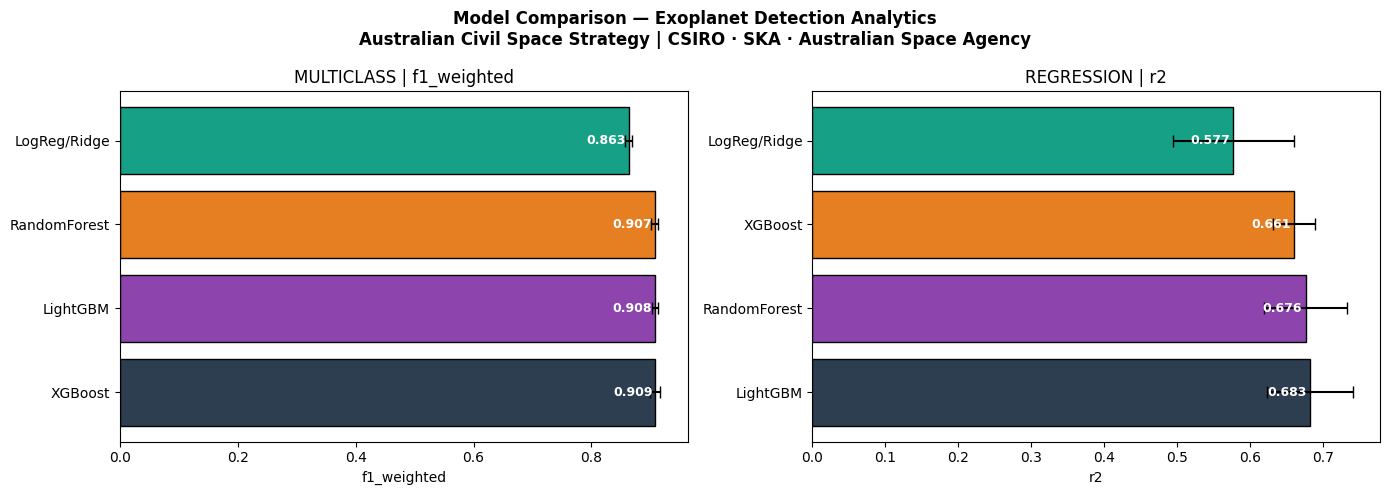

🏆 [MULTICLASS] Best: XGBoost | Score: 0.9085
🏆 [REGRESSION] Best: LightGBM | Score: 0.6826


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Exoplanet Detection Analytics\nAustralian Civil Space Strategy | CSIRO · SKA · Australian Space Agency',
             fontsize=12, fontweight='bold')

colors = ['#2c3e50','#8e44ad','#e67e22','#16a085']
best_info = {}

for ax, (task_name, task_data) in zip(axes, all_results.items()):
    res_df = pd.DataFrame(task_data['results']).T.sort_values('mean', ascending=False)
    metric = task_data['metric']
    bars = ax.barh(res_df.index, res_df['mean'], xerr=res_df['std'],
                   color=colors[:len(res_df)], edgecolor='black', capsize=4)
    ax.set_title(f'{task_name.upper()} | {metric}')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, res_df['mean']):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)
    best_info[task_name] = {'name': res_df.index[0], 'score': res_df['mean'].iloc[0],
                            'std': res_df['std'].iloc[0], 'res_df': res_df}

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

for task_name, info in best_info.items():
    print(f'🏆 [{task_name.upper()}] Best: {info["name"]} | Score: {info["score"]:.4f}')

## 8. 🔎 Error Analysis & Feature Importance

                 precision    recall  f1-score   support

        Imaging       0.71      0.62      0.67         8
   Microlensing       0.60      0.75      0.67         4
          Other       1.00      0.40      0.57         5
Radial Velocity       0.99      0.97      0.98       111
        Transit       0.92      0.97      0.94        79

       accuracy                           0.94       207
      macro avg       0.84      0.74      0.77       207
   weighted avg       0.94      0.94      0.94       207



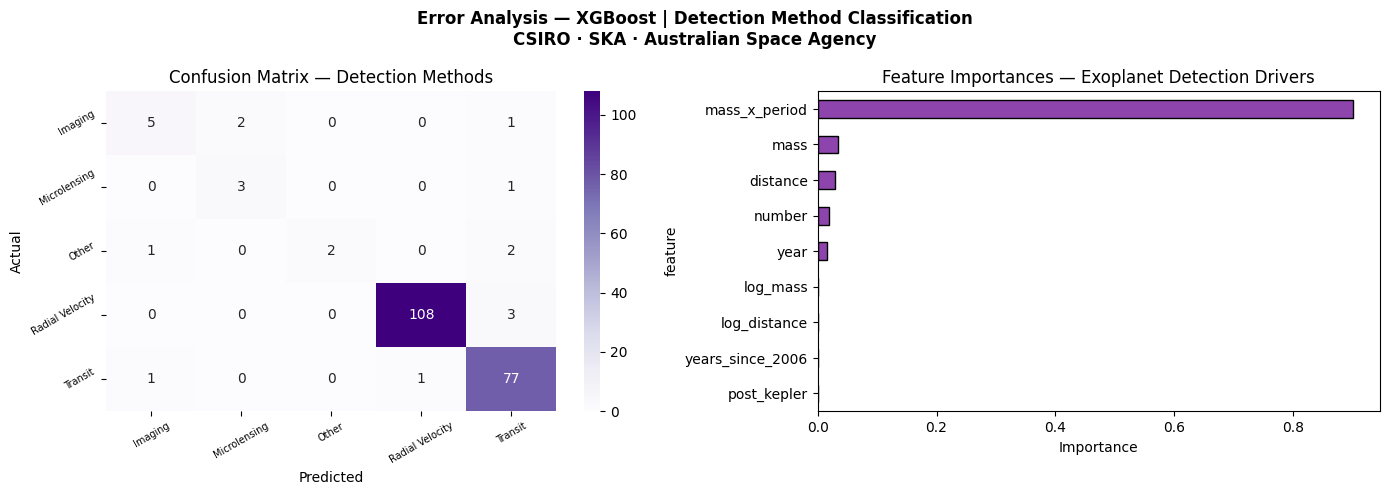

In [9]:
# Focus on multiclass classification for error analysis
task_key   = 'multiclass' if 'multiclass' in all_results else list(all_results.keys())[0]
task_data  = all_results[task_key]
best_name  = best_info[task_key]['name']
best_model = task_data['models'][best_name]
X_in = task_data['X_scaled'] if best_name == 'LogReg/Ridge' else task_data['X_imp'].values
y    = task_data['y']

X_tr, X_te, y_tr, y_te = train_test_split(X_in, y, test_size=0.2,
                                           random_state=SEED, stratify=y)
best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Error Analysis — {best_name} | Detection Method Classification\nCSIRO · SKA · Australian Space Agency',
             fontsize=12, fontweight='bold')

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=method_classes, yticklabels=method_classes)
axes[0].set_title('Confusion Matrix — Detection Methods')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(rotation=30, labelsize=7)
print(classification_report(y_te, y_pred, target_names=method_classes))

feat_cols = task_data['X_imp'].columns.tolist()
if hasattr(best_model, 'feature_importances_'):
    imp_vals = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    imp_vals = np.abs(best_model.coef_).mean(axis=0)
else:
    imp_vals = np.zeros(len(feat_cols))

fi_df = pd.DataFrame({'feature': feat_cols, 'importance': imp_vals}).sort_values('importance', ascending=True)
fi_df.plot(kind='barh', x='feature', y='importance', ax=axes[1],
           color='#8e44ad', edgecolor='black', legend=False)
axes[1].set_title('Feature Importances — Exoplanet Detection Drivers')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. 🚀 Deployment Readiness Checklist

In [10]:
best_clf_name = best_info.get('multiclass', best_info.get('binary', {'name':'N/A','score':0}))['name']
best_clf_score = best_info.get('multiclass', best_info.get('binary', {'name':'N/A','score':0}))['score']
best_reg_name  = best_info.get('regression', {'name':'N/A','score':0})['name']
best_reg_score = best_info.get('regression', {'name':'N/A','score':0})['score']

print('=' * 65)
print('  DEPLOYMENT READINESS CHECKLIST')
print('  Exoplanet Detection Analytics')
print('  Australian Space Agency · CSIRO · SKA · ARC · Dept of Industry')
print('=' * 65)

checklist = [
    ('Data Pipeline',         'Seaborn planets (OECD); CSV fallback; latin-1; 30K row cap'),
    ('Missing Values',        'SimpleImputer (median); orbital_period/mass have NaNs handled'),
    ('Feature Engineering',   'log transforms (period, mass, distance); post_kepler flag; mass×period'),
    ('Rare Class Handling',   'Rare detection methods consolidated into Other (top-4 kept)'),
    ('Dual Task Modelling',   'Multiclass classification (method) + Regression (log orbital period)'),
    ('Encoding',              'LabelEncoder for detection method; numeric features only in X'),
    ('Scaling',               'StandardScaler for LogReg; raw values for tree models'),
    ('Cross-Validation',      '3-Fold Stratified CV; F1-weighted (clf) + R² (regression)'),
    ('Best Classifier',       f'{best_clf_name} | F1-weighted: {best_clf_score:.4f}'),
    ('Best Regressor',        f'{best_reg_name} | R²: {best_reg_score:.4f}'),
    ('Error Analysis',        'Confusion matrix (multiclass) + feature importance ranking'),
    ('Policy Alignment',      'Australian Civil Space Strategy 2019–2028; ARC Discovery grants'),
    ('Privacy/Ethics',        'Public astronomical data; no PII; fully open science compliant'),
    ('Explainability',        'Feature importance maps orbital/physical properties to method'),
    ('Reproducibility',       'SEED=42; all transforms serialisable via joblib'),
    ('Production Path',       'Export → Azure ML · Databricks MLflow · CSIRO data pipelines'),
]

for item, detail in checklist:
    print(f'  ✅ {item:<28} {detail}')

print('\n' + '=' * 65)
print(f'  🏆 CLASSIFIER WINNER: {best_clf_name} (F1: {best_clf_score:.4f})')
print(f'  🏆 REGRESSOR WINNER:  {best_reg_name} (R²: {best_reg_score:.4f})')
print('=' * 65)
print()
print('📌 Notebook #54 of 100+ | Author: Dean (deanbatur | Deanmeisong)')
print('🏛️  Australian Government ML Portfolio | Space & Astronomy Analytics')

  DEPLOYMENT READINESS CHECKLIST
  Exoplanet Detection Analytics
  Australian Space Agency · CSIRO · SKA · ARC · Dept of Industry
  ✅ Data Pipeline                Seaborn planets (OECD); CSV fallback; latin-1; 30K row cap
  ✅ Missing Values               SimpleImputer (median); orbital_period/mass have NaNs handled
  ✅ Feature Engineering          log transforms (period, mass, distance); post_kepler flag; mass×period
  ✅ Rare Class Handling          Rare detection methods consolidated into Other (top-4 kept)
  ✅ Dual Task Modelling          Multiclass classification (method) + Regression (log orbital period)
  ✅ Encoding                     LabelEncoder for detection method; numeric features only in X
  ✅ Scaling                      StandardScaler for LogReg; raw values for tree models
  ✅ Cross-Validation             3-Fold Stratified CV; F1-weighted (clf) + R² (regression)
  ✅ Best Classifier              XGBoost | F1-weighted: 0.9085
  ✅ Best Regressor               LightGBM | R²: 